In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [29]:
# Cell 2: Load data
df = pd.read_csv('used_cars_mock.xls')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head(15)

Dataset shape: (10000, 10)

First 5 rows:


,car_id,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price
0,1,Honda,Model A,2020,50757.0,Petrol,Manual,7,30,999999
1,2,Fiat,Model B,2030,NaN,Hybrid,Automatic,1,1,19076
2,3,Audi,Model C,2025,-500.0,Petrol,Automatic,12,1,29629
3,4,VW,Model B,2023,10661.0,XYZ,Automatic,10,20,18132
4,5,Dacia,Model C,2015,126515.0,Petrol,Manual,7,30,0
5,6,VW,Model C,2015,121974.0,Petrol,Manual,12,1,500
6,7,BMW,Model B,2005,247373.0,Petrol,Automatic,4,10,500
7,8,Ford,Model B,2025,3210.0,Hybrid,Automatic,11,1,21820
8,9,Mercedes,Model A,2023,34565.0,Diesel,Automatic,11,1,21380
9,10,BMW,Model A,2025,13173.0,Petrol,Automatic,8,30,33616


In [30]:
df_clean = df.copy()

In [31]:


# Fix 1: Remove future cars (keep only up to current year)
df_clean = df_clean[df_clean['year'] <= 2025]

In [38]:
# Fix 2: Remove impossible prices (0 or > 200,000)
df_clean = df_clean[(df_clean['price'] > 500) & (df_clean['price'] < 200000)]


In [39]:

df_clean = df_clean[df_clean['mileage'] >= 0]


In [40]:

df_clean.loc[df_clean['fuel_type'] == 'XYZ', 'fuel_type'] = 'Petrol'

In [41]:

df_clean['age'] = 2025 - df_clean['year']
median_mileage_by_age = df_clean.groupby('age')['mileage'].transform('median')
df_clean['mileage'].fillna(median_mileage_by_age, inplace=True)

print(f"Rows removed: {len(df) - len(df_clean)} ({100*(1-len(df_clean)/len(df)):.1f}%)")
print(f"Clean dataset shape: {df_clean.shape}")

Rows removed: 1171 (11.7%)
Clean dataset shape: (8829, 11)


C:\Users\lenovo\AppData\Local\Temp\ipykernel_16204\3434729961.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['mileage'].fillna(median_mileage_by_age, inplace=True)


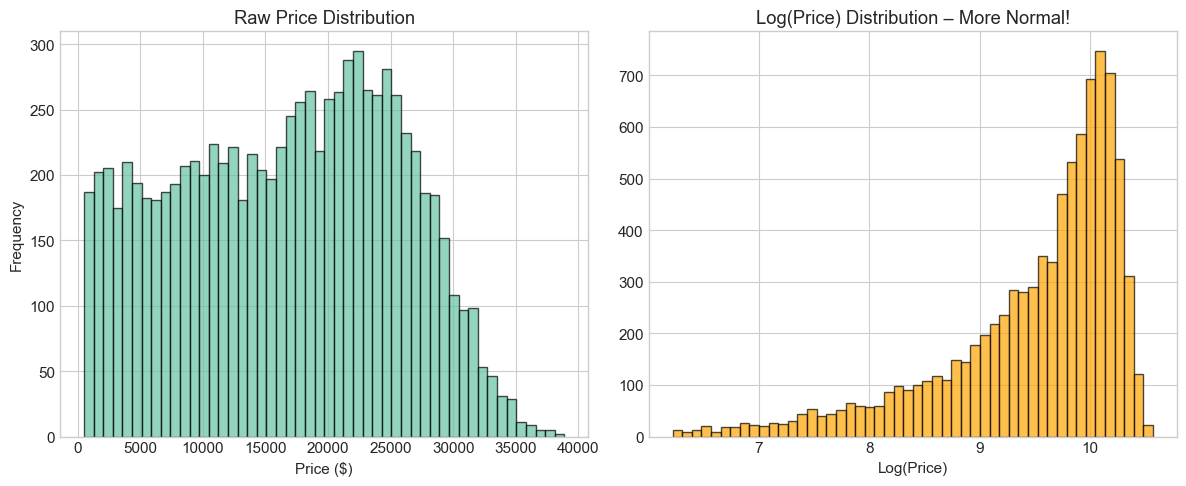

In [42]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw price
axes[0].hist(df_clean['price'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Raw Price Distribution')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')

# Log-transformed price
axes[1].hist(np.log1p(df_clean['price']), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Log(Price) Distribution – More Normal!')
axes[1].set_xlabel('Log(Price)')

plt.tight_layout()
plt.show()